# Developing python implementation of BASL

In [1]:
## Setting "base directory" for allowing imports
import os
import sys
import warnings

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator, CreditDataSample
from berebasl.BASL.BASL import accept_based_on_top_percentent_of_arbitrary_var
from berebasl.BASL.classifiers import TorchLogistic

import torch

In [2]:
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

initial_seed = 1807

#Acceptance loop parametrization
init_sample = 100
sample_size = 100
holdout_sample = 3000
num_gens = 300
top_percent = 0.2

determinstic_mixture_weights = True

data_gen = CreditDataGenerator.init_with_internal_logic(
    count_covariates=2,
    mean_bad_diff=torch.tensor([1.0,2.0]),
    covars = {
        "bad" : torch.tensor([[1.0, 0.2], [0.2,1.0]]),
        "good" : torch.tensor([[1.0,-0.2], [-0.2,1.0]])
    },
    iid = False,
    mixture_weights=None,
    bad_ratio = 0.5,
    noise_var=0.0,
    device = device,
    seed_credit_data_gen=initial_seed,
    #dtype=torch.get_default_dtype()
)

# Initial population
data_gen.manual_seed(initial_seed)
features, default_flag = data_gen.sample(100)

accepts = accept_based_on_top_percentent_of_arbitrary_var(
    features, 
    default_flag,
    var_for_rule=0,
    top_percent=top_percent,
    default_value = CreditDataGenerator.bad_good_encoding["bad"]
)

credit_data = CreditData(features, default_flag, accepts)

## Understanding `biasAwareSelfLearning`

The signature:

```r
biasAwareSelfLearning <- function(accepts,
                                  rejects,
                                  target           = 'BAD', 
                                  filtering_beta   = c(0, 1),
                                  weak_learner     = 'classif.logreg',
                                  strong_learner   = 'classif.logreg',
                                  holdout_percent  = 0.1,
                                  sampling_percent = 1,
                                  labeling_percent = 0.01, 
                                  multiplier       = 1, 
                                  max_iterations   = 3,
                                  early_stop       = F,
                                  silent           = F) 
```

The call
```r
# BASL parameters
  filtering_beta   <- c(0.01, 0.99)
  holdout_percent  <- 0.1
  labeling_percent <- 0.1
  sampling_percent <- 0.8
  multiplier       <- 2
  max_iterations   <- 5
  early_stop       <- T
  
  # label rejected cases
  rej_labels <- biasAwareSelfLearning(accepts          = current_accepts, 
                                      rejects          = current_rejects,
                                      target           = 'BAD', 
                                      filtering_beta   = filtering_beta,
                                      weak_learner     = 'classif.logreg',
                                      strong_learner   = 'classif.logreg',
                                      holdout_percent  = holdout_percent,
                                      labeling_percent = labeling_percent, 
                                      sampling_percent = sampling_percent,
                                      multiplier       = multiplier, 
                                      max_iterations   = max_iterations,
                                      early_stop       = early_stop,
                                      silent           = T)
```

There are a couple of parts in the algorithm:

0. **Preparation:** defines several variables. 
    * specially interesting is that it creates "holdout samples" from the accepts when `early_stop == T`
    * it also defines as `bm_metric` the auc.
1. **Reject Filtering** It occurs if `filtering_beta != c(0,1)` (as the call is done inside the acceptance loop). The filtering is done via the function `filteringStage`

In [ ]:
from sklearn.ensemble import IsolationForest
from typing import Callable, Union
import numpy as np

class BASL:
    filtering_beta : torch.Tensor #filtering_beta in algorithm are both of these
    weak_learner : Callable[[torch.Tensor], torch.Tensor]
    strong_learner : Callable[[torch.Tensor], torch.Tensor]
    hold_out_percent : float
    labeling_percent : float
    multiplier : float
    max_iterations :int
    early_stop : bool
    isolation_forest : IsolationForest

    def __init__(
            self,
            filtering_quantiles : dict[str, float], #filtering_beta in algorithm are both of these
            weak_learner : Callable[[torch.Tensor], torch.Tensor],
            strong_learner : Callable[[torch.Tensor], torch.Tensor],
            hold_out_percent : float,
            labeling_percent : float,
            multiplier : float,
            max_iterations :int,
            early_stop : bool,
            isolation_forest : IsolationForest,
            bayesian_evaluator : "BayesianEvaluator"
    ):
        BASL.check_filtering_quantiles(filtering_quantiles)
        self.filtering_quantiles = filtering_quantiles
        
        self.weak_learner = weak_learner
        self.strong_learner = strong_learner
        self.hold_out_percent = float(hold_out_percent)
        if not (0 <= self.hold_out_percent <= 1):
            raise ValueError("hold_out_percent needs to be between 0 and 1")
        self.labeling_percent = float(labeling_percent)
        if not (0 <= self.labeling_percent <= 1):
            raise ValueError("labeling_percent needs to be between 0 and 1")
        
        self.multiplier = float(multiplier)
        self.max_iterations = int(max_iterations)
        if self.max_iterations < 1:
            raise ValueError("max_iterations needs to be at least 1")
        
        self.early_stop = bool(early_stop)
        self.isolation_forest = isolation_forest
        self.bayesian_evaluator = bayesian_evaluator

    @staticmethod
    def check_filtering_quantiles(filtering_quantiles) -> None:
        if not 0.0 <= filtering_quantiles['lower'] <= 1.0:
            raise ValueError("filtering_quantiles['lower'] must be in the interval [0, 1].")
        if not 0.0 <= filtering_quantiles['lower'] <= 1.0:
            raise ValueError("filtering_quantiles['upper'] must be in the interval [0, 1].")
        if filtering_quantiles['lower'] >= filtering_quantiles['upper']:
            raise ValueError(
                "filtering_quantiles['lower'] must be strictly smaller than filtering_quantiles['upper']."
            )

    @property
    def should_filter(self):
        return (self.filtering_quantiles['lower'] > 0) or (self.filtering_quantiles['upper'] <1)
    
    

    def self_learn(
            self,
            features_accept : torch.Tensor,
            default_flags_accept : torch.Tensor,
            features_reject : torch.Tensor,
            silent : bool = True
    ) -> torch.Tensor:
        pass

    def filter_rejects(
        self,
        features_rejects: torch.Tensor,
        return_index: bool = True,
    ) -> Union[np.ndarray, np.ndarray]:
        """
        Filters observations using a two-sided trimming strategy based on
        Isolation Forest normality scores.

        The function fits an Isolation Forest model on the provided feature
        matrix and computes the negative anomaly scores via
        ``IsolationForest.score_samples``. These scores induce a relative
        normality (similarity) ranking.

        Observations are retained if their score lies within the central
        quantile interval defined by ``lower_trim_quantile`` and
        ``upper_trim_quantile``. Consequently, both highly anomalous
        observations (lower tail) and overly typical observations
        (upper tail) are removed.

        This procedure corresponds to a two-sided percentile-based filtering
        scheme as described in Kozodoi et al. (2025), "Fighting Sampling Bias".

        Args:
            features_rejects (torch.Tensor):
                Feature matrix of shape ``(n_samples, n_features)``.
            return_index (bool, optional):
                If ``True``, return a boolean mask indicating retained
                observations. If ``False``, return the filtered feature
                matrix. Defaults to ``True``.

        Returns:
            torch.Tensor:
                If ``return_index`` is ``True``, a boolean array of shape
                ``(n_samples,)`` indicating which observations are retained.
                Otherwise, a feature matrix containing only the retained
                observations.
        """
        
        features = features_rejects.detach().numpy()
        self.isolation_forest.fit(features)
        normality_scores = self.isolation_forest.score_samples(features)

        lower_score_bound, upper_score_bound = np.quantile(
            normality_scores,
            [self.filtering_quantiles["lower"], self.filtering_quantiles["upper"]],
        )

        keep_mask = (
                (lower_score_bound <= normality_scores)
                & (normality_scores <= upper_score_bound)
        )
        keep_mask = torch.from_numpy(keep_mask)

        return keep_mask if return_index else features_rejects[keep_mask]

    def bayesian_evaluation( #Next step to implement
            self,
            features_accept : torch.Tensor,
            default_flag_accept : torch.Tensor,
            features_reject : torch.Tensor,
            *args,
            **kwargs
    ) -> torch.Tensor:
        pass
    
    def should_stop_early(self) -> bool:
        pass
    
    def label_rejects(self) -> torch.Tensor:
        pass
    
    
    


### Sensible `__init__` stuff or properties

In [4]:
import numpy as np

class DummyBASL:
    filtering_beta : torch.Tensor #filtering_beta in algorithm are both of these
    weak_learner : Callable[[torch.Tensor], torch.Tensor]
    strong_learner : Callable[[torch.Tensor], torch.Tensor]
    hold_out_percent : float
    labeling_percent : float
    multiplier : float
    max_iterations :int
    early_stop : bool
    isolation_forest : IsolationForest

    def __init__(
            self,
            filtering_quantiles : dict[str, float], #filtering_beta in algorithm are both of these
            weak_learner : Callable[[torch.Tensor], torch.Tensor],
            strong_learner : Callable[[torch.Tensor], torch.Tensor],
            hold_out_percent : float,
            labeling_percent : float,
            multiplier : float,
            max_iterations :int,
            early_stop : bool,
            isolation_forest : IsolationForest
    ):
        DummyBASL.check_filtering_quantiles(filtering_quantiles)
        self.filtering_quantiles = filtering_quantiles
        
        self.weak_learner = weak_learner
        self.strong_learner = strong_learner
        self.hold_out_percent = float(hold_out_percent)
        if not (0 <= self.hold_out_percent <= 1):
            raise ValueError("hold_out_percent needs to be between 0 and 1")
        self.labeling_percent = float(labeling_percent)
        if not (0 <= self.labeling_percent <= 1):
            raise ValueError("labeling_percent needs to be between 0 and 1")
        
        self.multiplier = float(multiplier)
        self.max_iterations = int(max_iterations)
        if self.max_iterations < 1:
            raise ValueError("max_iterations needs to be at least 1")
        
        self.early_stop = bool(early_stop)
        self.isolation_forest = isolation_forest


    @staticmethod
    def check_filtering_quantiles(filtering_quantiles) -> None:
        if not 0.0 <= filtering_quantiles['lower'] <= 1.0:
            raise ValueError("filtering_quantiles['lower'] must be in the interval [0, 1].")
        if not 0.0 <= filtering_quantiles['lower'] <= 1.0:
            raise ValueError("filtering_quantiles['upper'] must be in the interval [0, 1].")
        if filtering_quantiles['lower'] >= filtering_quantiles['upper']:
            raise ValueError(
                "filtering_quantiles['lower'] must be strictly smaller than filtering_quantiles['upper']."
            )

    @property
    def should_filter(self):
        return (self.filtering_quantiles['lower'] > 0) or (self.filtering_quantiles['upper'] <1)
    
    def filter_rejects(
        self,
        lower_trim_quantile: float,
        upper_trim_quantile: float,
        features_rejects: torch.Tensor,
        return_index: bool = True,
    ) -> Union[np.ndarray, np.ndarray]:
        """
        Filters observations using a two-sided trimming strategy based on
        Isolation Forest normality scores.

        The function fits an Isolation Forest model on the provided feature
        matrix and computes the negative anomaly scores via
        ``IsolationForest.score_samples``. These scores induce a relative
        normality (similarity) ranking.

        Observations are retained if their score lies within the central
        quantile interval defined by ``lower_trim_quantile`` and
        ``upper_trim_quantile``. Consequently, both highly anomalous
        observations (lower tail) and overly typical observations
        (upper tail) are removed.

        This procedure corresponds to a two-sided percentile-based filtering
        scheme as described in Kozodoi et al. (2025), "Fighting Sampling Bias".

        Args:
            ifo (IsolationForest):
                An unfit ``IsolationForest`` instance used to compute
                normality scores.
            lower_trim_quantile (float):
                Lower quantile boundary in the interval ``[0, 1]``.
                Observations with scores below this quantile are discarded.
            upper_trim_quantile (float):
                Upper quantile boundary in the interval ``[0, 1]``.
                Observations with scores above this quantile are discarded.
            features (np.ndarray):
                Feature matrix of shape ``(n_samples, n_features)``.
            return_index (bool, optional):
                If ``True``, return a boolean mask indicating retained
                observations. If ``False``, return the filtered feature
                matrix. Defaults to ``True``.

        Returns:
            np.ndarray:
                If ``return_index`` is ``True``, a boolean array of shape
                ``(n_samples,)`` indicating which observations are retained.
                Otherwise, a feature matrix containing only the retained
                observations.

        Raises:
            ValueError:
                If ``lower_trim_quantile`` or ``upper_trim_quantile`` are
                outside the interval ``[0, 1]`` or if
                ``lower_trim_quantile >= upper_trim_quantile``.
        """
        if not 0.0 <= lower_trim_quantile <= 1.0:
            raise ValueError("lower_trim_quantile must be in the interval [0, 1].")
        if not 0.0 <= upper_trim_quantile <= 1.0:
            raise ValueError("upper_trim_quantile must be in the interval [0, 1].")
        if lower_trim_quantile >= upper_trim_quantile:
            raise ValueError(
                "lower_trim_quantile must be strictly smaller than upper_trim_quantile."
            )

        self.ifo.fit(features)
        normality_scores = self.ifo.score_samples(features)

        lower_score_bound, upper_score_bound = np.quantile(
            normality_scores,
            [lower_trim_quantile, upper_trim_quantile],
        )

        keep_mask = (
                (lower_score_bound <= normality_scores)
                & (normality_scores <= upper_score_bound)
        )

        return keep_mask if return_index else features[keep_mask]

### Understanding `filteringStage`

Signature:

```r
filteringStage <- function(accepts, 
                           rejects, 
                           target    = 'BAD', 
                           beta      = c(0, 1),
                           num_trees = 100)
```

Call:

```r
filter_idx <- filteringStage(accepts   = train, # ifelse(early_stop, accepts[-holdout_idx_accepts, ], accepts)
                             rejects   = test,  # ifelse(early_stop, rejects[-holdout_idx_rejects, ], rejects)
                             beta      = filtering_beta, # From loop: c(0.01,0.99)
                             num_trees = 100)
```

In [5]:
from sklearn.ensemble import IsolationForest
import numpy as np

from typing import Union

forest = IsolationForest(n_estimators=100, max_samples="auto", random_state=1807)
def filter(
    self,
    lower_trim_quantile: float,
    upper_trim_quantile: float,
    features: np.ndarray,
    return_index: bool = True,
) -> Union[np.ndarray, np.ndarray]:
    """
    Filters observations using a two-sided trimming strategy based on
    Isolation Forest normality scores.

    The function fits an Isolation Forest model on the provided feature
    matrix and computes the negative anomaly scores via
    ``IsolationForest.score_samples``. These scores induce a relative
    normality (similarity) ranking.

    Observations are retained if their score lies within the central
    quantile interval defined by ``lower_trim_quantile`` and
    ``upper_trim_quantile``. Consequently, both highly anomalous
    observations (lower tail) and overly typical observations
    (upper tail) are removed.

    This procedure corresponds to a two-sided percentile-based filtering
    scheme as described in Kozodoi et al. (2025), "Fighting Sampling Bias".

    Args:
        ifo (IsolationForest):
            An unfit ``IsolationForest`` instance used to compute
            normality scores.
        lower_trim_quantile (float):
            Lower quantile boundary in the interval ``[0, 1]``.
            Observations with scores below this quantile are discarded.
        upper_trim_quantile (float):
            Upper quantile boundary in the interval ``[0, 1]``.
            Observations with scores above this quantile are discarded.
        features (np.ndarray):
            Feature matrix of shape ``(n_samples, n_features)``.
        return_index (bool, optional):
            If ``True``, return a boolean mask indicating retained
            observations. If ``False``, return the filtered feature
            matrix. Defaults to ``True``.

    Returns:
        np.ndarray:
            If ``return_index`` is ``True``, a boolean array of shape
            ``(n_samples,)`` indicating which observations are retained.
            Otherwise, a feature matrix containing only the retained
            observations.

    Raises:
        ValueError:
            If ``lower_trim_quantile`` or ``upper_trim_quantile`` are
            outside the interval ``[0, 1]`` or if
            ``lower_trim_quantile >= upper_trim_quantile``.
    """
    if not 0.0 <= lower_trim_quantile <= 1.0:
        raise ValueError("lower_trim_quantile must be in the interval [0, 1].")
    if not 0.0 <= upper_trim_quantile <= 1.0:
        raise ValueError("upper_trim_quantile must be in the interval [0, 1].")
    if lower_trim_quantile >= upper_trim_quantile:
        raise ValueError(
            "lower_trim_quantile must be strictly smaller than upper_trim_quantile."
        )

    self.ifo.fit(features)
    normality_scores = self.ifo.score_samples(features)

    lower_score_bound, upper_score_bound = np.quantile(
        normality_scores,
        [lower_trim_quantile, upper_trim_quantile],
    )

    keep_mask = (
        (lower_score_bound <= normality_scores)
        & (normality_scores <= upper_score_bound)
    )

    return keep_mask if return_index else features[keep_mask]
#keep_mask = filter(forest, lower_trim_quantile=0.01, upper_trim_quantile=0.99, features=features.numpy())


### Developing the flow of the original algorithm

In [6]:
data = credit_data.to_sample_dataset()

self = BASL(
    filtering_quantiles={"lower" : .01, "upper" : .99},
    weak_learner = TorchLogistic(
        n_features=credit_data.features.shape[-1],
        n_classes=2
    ),
    strong_learner = TorchLogistic(
        n_features=credit_data.features.shape[-1],
        n_classes=2
    ),
    hold_out_percent = 0.1,
    labeling_percent=0.01,
    multiplier=1,
    max_iterations=3,
    early_stop=True,
    isolation_forest=IsolationForest(n_estimators=100, max_samples="auto", random_state=1807)
)

#### Flow of the algorithm

In [7]:
if True:
    if True:
        if self.early_stop:
            data, hold_out_data = data.train_test_split(self.hold_out_percent)

        # percentage
        per_b = self.labeling_percent
        per_g = self.labeling_percent / self.multiplier

        something_that_happens_in_between = """
            train    <- accepts
            test     <- rejects
            raw_test <- rejects
            rm(list = c('accepts', 'rejects'))
        """

        eval_params = """
            bm_metric   <- mlr::auc
            bm_min_iter <- 10^2
            bm_max_iter <- 10^4
            bm_epsilon  <- 10^4
        """
        
        if self.should_filter:
            data.features_rejects = self.filter_rejects(data.features_rejects, return_index=False)

        


# Developing bayesianMetric

call:

```r
bayesianMetric(metric         = bm_metric, #auc
               model          = strong_model, #logit
               accepts        = holdout_accepts,
               rejects        = holdout_rejects,
               rejects_prior  = rejects_preds$data$prob.BAD, 
               min_iterations = bm_min_iter, # 10^2
               max_iterations = bm_max_iter, # 10^4
               epsilon        = bm_epsilon,  # 10^4 (likely -4)
               seed           = 1)
```

whereby

```r
rejects_preds <- predict(strong_model, newdata = holdout_rejects)
```

One of the main differences when developing the bayesian metric in torch than the original R implementation is that the metric values do not get stored in a vector. In the R implementation the difference between means is calculated as
```r
dmean <- abs(mean(vals[1:n]) - mean(vals[1:(n-1)]))
```

Let $M = \{m_1, \ldots, m_n\} \subseteq \mathbb{R}$ be the set of the metrics up to iteration $n \in \mathbb{N}$ and $\bar{M}_{:k} := \frac{1}{k} \sum_{i = 1}^{k} m_i$, with $k \leq n$. Then with

$$
\Delta \bar{M}_{:n} := \bar{M}_{:n} - \bar{M}_{:(n-1)}
$$

we can see that $\texttt{dmean} = \left|\Delta \bar{M}_{:n} \right|$. Furthermore we can see with simple transformations that

$$
\Delta \bar{M}_{:n} = \frac{m_n}{n} + \sum_{i = 1}^{n-1} \frac{m_i}{n} - \sum_{j=1}^{n-1} \frac{m_j}{n-1}
$$

which for any finite $n \in \mathbb{N}$ can also be rewritten as

$$
\Delta \bar{M}_{:n} = \frac{m_n}{n} + \sum_{i = 1}^{n-1} \underbrace{\frac{m_i}{n} - \frac{m_i}{n-1}}_{\frac{1}{n}\frac{-m_i}{n-1}}
$$
$$
\Leftrightarrow \Delta \bar{M}_{:n} = \frac{m_n}{n} - \frac{1}{n} \bar{M}_{:(n-1)} = \frac{m_n - \bar{M}_{:(n-1)}}{n}
$$

In the code it is also used the fact that for $n>1$

$$
\bar{M}_{:n} = \frac{m_n}{n} + \frac{n-1}{n} \bar{M}_{:(n-1)}
$$
and since $\bar{M}_{:1} = \frac{m_1}{1}$ we can calculate $\bar{M}_{:n}$ sequentially with the equation above by defining $\bar{M}_{:0} \equiv 0$, therefore eliminating the need to create the vector/tensor containing $M$. Furthermore it also allows for a quick and vectorizable generalization when the metric is being calculated for a "batch of batches" or a "batch of batches of batches" or ...

This formulations also reduce the time complexity (measured as MAC operations) from $O(n^2)$ to $O(n)$ ($n$ being the iterations needed until convergence) and the memory complexity from $O(n)$ to $O(1)$ (given a constant "super-batch" size), which is nice besides the obvious advantages of a vectorizable operations across "super-batches".

In [ ]:
from typing import Optional, Callable

class BayesianEvaluator:
    # Only implemented for binary classification right now
    # multiclass classification should be straight forward from here
    def __init__(
            self,
            model,
            min_iterations : int,
            max_iterations : int,
            epsilon : float,
            metric : Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
            predict_model : Callable[["self.model", torch.Tensor], torch.Tensor] = lambda model, features_rejects : model.predict_proba(features_rejects)[..., 1],
            seed : Optional[int] = 1807,
            device : Optional[torch.device] = None
    ):
        self.model = model
        self.min_iterations = int(min_iterations)
        self.max_iterations = int(max_iterations)
        self.epsilon = float(epsilon)

        self.predict_model = predict_model
        self.metric = metric

        if device is None:
            device=torch.get_default_device()

        self.rng = torch.Generator(device=device)
        if seed is not None:
            self.rng.manual_seed(seed)

    def manual_seed(self, seed : int):
        self.rng.manual_seed(seed)

    def rng_to_device(self, device : torch.device, seed : Optional[int] = None, set_same_initial_seed : bool = True):
        if seed is None and set_same_initial_seed:
            seed = self.rng.initial_seed()

        self.rng = torch.Generator(device=device)

        if seed is not None:
            self.rng.manual_seed(seed)


    def model_prediction(self, features_rejects):
        return self.predict_model(self.model, features_rejects)
    
    def sample_prior(self, prior_probs : torch.Tensor) -> torch.Tensor:
        return torch.bernoulli(prior_probs, generator=self.rng)
    
    def evaluate(
            self, 
            data : CreditDataSample, 
            rejects_prior_probs : torch.Tensor
        ) -> torch.Tensor:
        """
        Note: The calculation of metrics_mean_absdiff bases on the fact that
        $$
        E_j - E_{j-1} = (M_j - E_{j-1})/j
        $$
        with $M_j$ the metric evaluated on the evaluation set with 
        """
        # data.features_accepts has shape [..., N, k] with k being the amount of features
        # just like data.features_rejects. Then data.default_flag_accepts.shape = [..., N]
        # so the same leading dimensions as the features
        preds_accept = self.model_prediction(data.features_accepts)
        preds_reject = self.model_prediction(data.features_rejects)

        joint_preds = torch.cat([preds_accept, preds_reject], dim=-1)

        
        metric_mean_up_to_last_it = torch.full(size = data.default_flag_accepts.shape[:-1], fill_value=0.0)
        mask_nonconverged = torch.full(size = data.default_flag_accepts.shape[:-1], fill_value=True)

        should_stop = False

        for it_nr in range(1, self.max_iterations + 1):
            reject_pseudo_labels = self.sample_prior(rejects_prior_probs)
            joint_labels = torch.cat([data.default_flag_accepts, reject_pseudo_labels], dim=-1)

            new_metric = self.metric(joint_preds, joint_labels)

            contribution_to_mean_of_new_metric = new_metric / it_nr

            should_check_convergence = it_nr >= self.min_iterations

            if should_check_convergence:
                metrics_mean_absdiff = (contribution_to_mean_of_new_metric - metric_mean_up_to_last_it/it_nr).abs()
                converged_in_current = metrics_mean_absdiff < self.epsilon

            metric_mean_up_to_last_it[mask_nonconverged] = (
                ((it_nr-1)/it_nr) * metric_mean_up_to_last_it[mask_nonconverged] + contribution_to_mean_of_new_metric[mask_nonconverged]
            )

            if should_check_convergence:
                mask_nonconverged = mask_nonconverged & ~converged_in_current
                should_stop = not mask_nonconverged.any()

            if should_stop:
                break

        return metric_mean_up_to_last_it

## Testing vectorization across "batches of batches"

In the R implementation we would need to loop through `bayesianMetric` to calculate the same bayesian metric for a batch of `data.frames`. With proper masking and a metric that calculates in a parallelizable way across batches, `BayesianEvaluator.evaluate` can manage such vectorization.

To check weather both methods in deed work the same, I check with the same logic as the R-Implementation weather I get the same results (with `torch.allclose`) with the chosen "update method" or not.

The first step is to create a dataset and model which work with batched data. A simple way is to "make batched" a sample of the credit data

In [ ]:
# Initial population
B, N = 16, 100
data_gen.manual_seed(1807)
features, default_flag = data_gen.sample(B * N)

# Generate accepts vector
accepts = accept_based_on_top_percentent_of_arbitrary_var(
    features, 
    default_flag,
    var_for_rule=0,
    top_percent=0.2, #Ensures batching by B will be possible as 100 * [0.2, 0.8] = [20, 80]
    default_value = CreditDataGenerator.bad_good_encoding["bad"]
)

# Save in credit data to get then a CreditDataSample in a clean way
credit_data = CreditData(features, default_flag, accepts)
sample_for_batching = credit_data.to_sample_dataset()

# Create model and fit it on all accepts
features_count = sample_for_batching.features_accepts.size(-1)
model = TorchLogistic(n_features=features_count)
model = model.fit(X=sample_for_batching.features_accepts, y = sample_for_batching.default_flag_accepts)
## Leave model in eval mode
model.eval()

# Reshape the data tensors and leave them saved like that
tensor_names = ["features_accepts", "features_rejects", "default_flag_accepts"]
for n in tensor_names:
    t = getattr(sample_for_batching, n)
    setattr(sample_for_batching, n, t.reshape(B, -1, *t.shape[1:]))

The second step is to create a metric which will work (in a vectorized manner) considering the type of labels. In our case the labels will have a shape `[B, N]`. As a metric the binary cross entropy is selected with mean reduction.

In [ ]:
def bce_with_custom_reduction(preds, labels, reduction = lambda unred_bce : torch.mean(unred_bce, dim=-1)):
    unreduced_bce = torch.nn.functional.binary_cross_entropy(preds, labels, reduction='none').detach() # [B, N]
    return reduction(unreduced_bce) # [B] - in case of the default reduction function

The last step is the evaluation itself. To do so the code of `BayesianEvaluator.evaluate` was taken with the parallel logic on how to compute the mean with a `val_vector`, which gets updated sequentially as well only for the cases where convergence has not been achieved yet

In [220]:
import pandas as pd # for reporting

data : CreditDataSample = sample_for_batching
rejects_prior_probs : torch.Tensor = model.predict_proba(sample_for_batching.features_rejects)[..., 1]
metric : Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = bce_with_custom_reduction
bayesian_evaluator = BayesianEvaluator(
    model = model,
    min_iterations=1e2,
    max_iterations=1e4,
    epsilon=1e-6,
    predict_model=lambda model, features_rejects : model.predict_proba(features_rejects)[..., 1],
    seed=1807,
    device = sample_for_batching.features_accepts.device
)

if True:
    if True:
        preds_accept = bayesian_evaluator.predict_model(bayesian_evaluator.model, data.features_accepts)
        preds_reject = bayesian_evaluator.predict_model(bayesian_evaluator.model, data.features_rejects)

        joint_preds = torch.cat([preds_accept, preds_reject], dim=-1)

        
        leading_dims = data.default_flag_accepts.shape[:-1]
        metric_mean_up_to_last_it = torch.full(size = leading_dims, fill_value=0.0)
        mask_nonconverged = torch.full(size = leading_dims, fill_value=True)

        should_stop = False

        vals_vector = torch.full(size=torch.Size([bayesian_evaluator.max_iterations])+leading_dims, fill_value=torch.nan, dtype=data.features_accepts.dtype)
        non_converged_flags = torch.full(size = leading_dims, fill_value=True)
        rtol_atol_spec = {"atol" : 1e-9, "rtol" : 1e-6}

        metric_means_diffs = []
        var_names = [f"V{b}" for b in range(B)]



        for it_nr in range(1, bayesian_evaluator.max_iterations + 1):

            reject_pseudo_labels = bayesian_evaluator.sample_prior(rejects_prior_probs)
            joint_labels = torch.cat([data.default_flag_accepts, reject_pseudo_labels], dim=-1)

            new_metric = metric(joint_preds, joint_labels)

            contribution_to_mean_of_new_metric = new_metric / it_nr

            non_converged_idx = non_converged_flags.nonzero().flatten()
            vals_vector[it_nr-1, non_converged_idx] = new_metric[non_converged_idx]

            should_check_convergence = it_nr >= bayesian_evaluator.min_iterations

            current_mean = vals_vector[:(it_nr)].nanmean(dim=0)

            if should_check_convergence:
                metrics_mean_absdiff = (contribution_to_mean_of_new_metric - metric_mean_up_to_last_it/it_nr).abs()
                long_metrics_mean_abs_diff = (current_mean - vals_vector[:(it_nr-1)].nanmean(dim=0)).abs()

                assert torch.allclose(metrics_mean_absdiff[mask_nonconverged], long_metrics_mean_abs_diff[mask_nonconverged], **rtol_atol_spec)

                converged_in_current = metrics_mean_absdiff < bayesian_evaluator.epsilon
                non_converged_flags[converged_in_current.nonzero().flatten()] = False


            metric_mean_up_to_last_it[mask_nonconverged] = (
                ((it_nr-1)/it_nr) * metric_mean_up_to_last_it[mask_nonconverged] + contribution_to_mean_of_new_metric[mask_nonconverged]
            )

            metric_means_diffs.append(pd.Series(current_mean - metric_mean_up_to_last_it, name=it_nr, index=var_names))

            assert torch.allclose(current_mean, metric_mean_up_to_last_it, **rtol_atol_spec)

            if should_check_convergence:
                mask_nonconverged = mask_nonconverged & ~converged_in_current
                should_stop = not mask_nonconverged.any()

            if should_stop:
                break
            

The code not throwing an assertion error already shows that the logic works. It is still sensible to check the gathered data on the differences

In [225]:
metric_means_diffs = pd.DataFrame(metric_means_diffs)
metric_means_diffs.describe()

,V0,V1,V2,V3,V4,V5,V6,V7
count,3.270000e+02,3.270000e+02,3.270000e+02,3.270000e+02,3.270000e+02,3.270000e+02,3.270000e+02,3.270000e+02
mean,1.989574e-16,-5.432284e-17,1.660242e-16,-3.184676e-16,-3.089611e-17,-2.590520e-16,-4.169278e-16,1.517644e-16
std,1.610345e-16,1.207628e-16,1.166266e-16,1.651479e-16,1.265664e-16,3.090832e-16,3.443651e-16,1.952198e-16
min,-2.220446e-16,-4.440892e-16,-2.220446e-16,-7.771561e-16,-3.330669e-16,-4.440892e-16,-6.661338e-16,-2.220446e-16
25%,1.110223e-16,-1.110223e-16,1.110223e-16,-3.330669e-16,-1.110223e-16,-4.440892e-16,-6.661338e-16,-1.110223e-16
50%,2.220446e-16,0.000000e+00,2.220446e-16,-3.330669e-16,0.000000e+00,-4.440892e-16,-6.661338e-16,2.220446e-16
75%,3.330669e-16,0.000000e+00,2.220446e-16,-3.330669e-16,0.000000e+00,-1.110223e-16,0.000000e+00,3.330669e-16
max,6.661338e-16,2.220446e-16,4.440892e-16,1.110223e-16,4.440892e-16,6.661338e-16,4.440892e-16,5.551115e-16


All the errors being smaller than $10^{-15}$ shows definetely, that the calculations do work as they should, as this error magnitude is what one would expect out of floating point imprecissions when using `float64`

### Developing a vectorized AUROC option (ChatGPT generated)

In [56]:
from torchmetrics.classification import BinaryAUROC

def batched_auroc_pairwise(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Compute AUROC independently for B datasets using pairwise comparisons,
    with tie-aware averaging (pos == neg contributes 0.5).

    Args:
        preds:   Tensor of shape [B, N], prediction scores.
        targets: Tensor of shape [B, N], binary labels {0,1}.

    Returns:
        auc: Tensor of shape [B], AUROC per mini-dataset.
    """
    B, N = preds.shape

    pos_mask = targets.bool()
    neg_mask = ~pos_mask

    # Extract positive and negative scores
    pos_scores = preds[pos_mask].view(B, -1)  # [B, P]
    neg_scores = preds[neg_mask].view(B, -1)  # [B, Q]

    # Pairwise score differences: [B, P, Q]
    diff = pos_scores.unsqueeze(-1) - neg_scores.unsqueeze(-2)

    # Contributions:
    # diff > 0  -> 1
    # diff == 0 -> 0.5
    # diff < 0  -> 0
    contrib = (diff > 0).to(preds.dtype) + 0.5 * (diff == 0).to(preds.dtype)

    auc = contrib.mean(dim=(-1, -2))
    return auc

def batched_auroc_torchmetrics(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    metric = BinaryAUROC()
    return torch.stack([
        metric(preds[b], targets[b])
        for b in range(preds.shape[0])
    ])

def batched_auroc_trapz(
    preds: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Batched AUROC computed via explicit ROC construction with
    grouped thresholds and trapezoidal integration.

    Matches torchmetrics.BinaryAUROC semantics.

    Args:
        preds:   [B, N] prediction scores
        targets: [B, N] binary labels {0,1}

    Returns:
        auc: [B] AUROC per mini-dataset
    """
    B, N = preds.shape
    device = preds.device

    # Sort by descending score
    order = preds.argsort(dim=-1, descending=True)
    sorted_preds = preds.gather(dim=-1, index=order)
    sorted_targets = targets.gather(dim=-1, index=order)

    # Count positives / negatives
    P = sorted_targets.sum(dim=-1)
    Q = N - P

    # Cumulative true/false positives
    tps = torch.cumsum(sorted_targets, dim=-1)
    fps = torch.cumsum(1 - sorted_targets, dim=-1)

    # Identify score changes (threshold boundaries)
    score_change = torch.ones_like(sorted_preds, dtype=torch.bool)
    score_change[:, 1:] = sorted_preds[:, 1:] != sorted_preds[:, :-1]

    # Keep only points where ROC actually changes
    tps = tps[score_change].view(B, -1)
    fps = fps[score_change].view(B, -1)

    # Normalize to TPR / FPR
    tpr = tps / P.unsqueeze(-1)
    fpr = fps / Q.unsqueeze(-1)

    # Add (0,0) explicitly
    zero = torch.zeros(B, 1, device=device)
    tpr = torch.cat([zero, tpr], dim=-1)
    fpr = torch.cat([zero, fpr], dim=-1)

    # Trapezoidal integration
    auc = torch.trapz(tpr, fpr, dim=-1)

    return auc


In [43]:
def sample_batch(B: int, N: int, data_gen, model):
    random_permutation = torch.randperm(N*B)
    features, targets = [t[random_permutation].reshape(B, -1, *t.shape[1:]) for t in data_gen.sample(B*N)]
    model = model.fit(features, targets)
    model.eval()
    preds = model.predict_proba(features)[..., 1]

    return preds, targets


In [60]:
import pandas as pd

B, N = 64, 500
data_gen.manual_seed(1807)
feature_count = data_gen.good_mixture.cov_chol_decomp.size(-1)
model = TorchLogistic(n_features=feature_count)
rtol_atol_spec = {"atol" : 1e-6, "rtol" : 1e-6}

cols = [f"B{b}" for b in range(B)]

diffs = []

trial_count = 100
for trial_nr in range(trial_count):
    if (trial_nr+1)%10 == 0:
        print("Beginning trial nr", trial_nr)
    preds, targets = sample_batch(B, N, data_gen, model)

    auc_trapz = batched_auroc_trapz(preds, targets)
    auc_tm = batched_auroc_torchmetrics(preds, targets)
    auc_approx = batched_auroc_pairwise(preds, targets)

    diffs.append(
        pd.Series(auc_tm - auc_trapz, index = cols, name = (trial_nr, "trapz"))
    )
    diffs.append(
        pd.Series(auc_tm - auc_approx, index = cols, name = (trial_nr, "approx"))
    )

    if not torch.allclose(auc_trapz, auc_tm, **rtol_atol_spec):
        raise AssertionError(
            f"Pairwise vs Rank mismatch at trial {trial_nr}\n"
            f"{auc_trapz}\n{auc_tm}"
        )

Beginning trial nr 9
Beginning trial nr 19
Beginning trial nr 29
Beginning trial nr 39
Beginning trial nr 49
Beginning trial nr 59
Beginning trial nr 69
Beginning trial nr 79
Beginning trial nr 89
Beginning trial nr 99


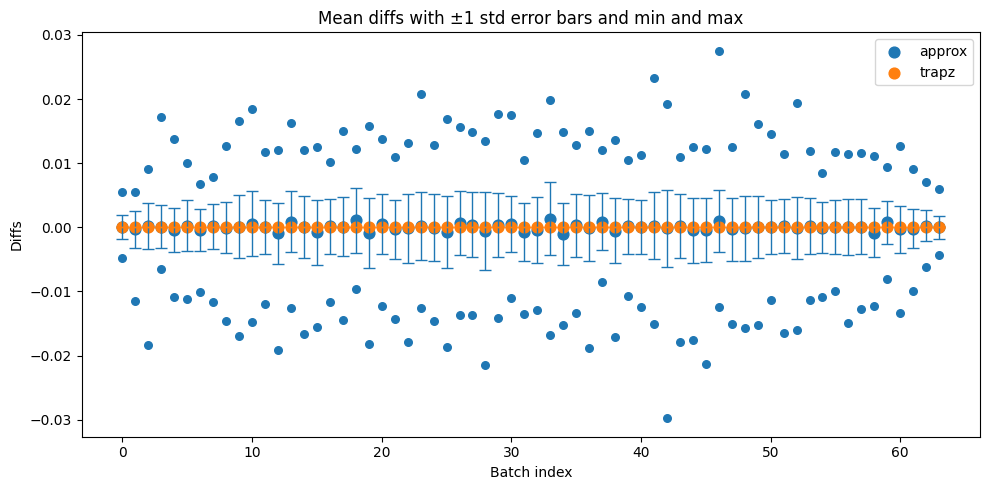

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# diffs is your original DataFrame
diffs = pd.DataFrame(diffs)

# grouped has shape: index = original columns, columns = ["mean", "std"]
grouped = diffs.groupby(level=1).agg(["mean", "std", "max", "min"])

# Extract x positions (the first-level column names)
x = np.arange(diffs.shape[1])

groups = grouped.index
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

for idx, g in enumerate(groups):
    plt_data = grouped.loc[g].unstack()


    # Scatter points
    ax.scatter(x, plt_data["mean"].values, s=60, label=g, c=default_colors[idx])
    ax.scatter(x, plt_data["min"].values, s=30, c=default_colors[idx])
    ax.scatter(x, plt_data["max"].values, s=30, c=default_colors[idx])

    # Error bars (±1 std)
    ax.errorbar(
        x,
        plt_data["mean"].values,
        yerr=plt_data["std"].values,
        fmt="none",          # no connecting line
        ecolor=default_colors[idx],      # error bar color (keeps default point colors)
        capsize=4,
        linewidth=1
    )


ax.set_xlabel("Batch index")
ax.set_ylabel("Diffs")
ax.set_title("Mean diffs with ±1 std error bars and min and max")

ax.legend()

plt.tight_layout()
plt.show()


In [79]:
import pandas as pd
import time

B, N = 64, 500
data_gen.manual_seed(1807)
feature_count = data_gen.good_mixture.cov_chol_decomp.size(-1)
model = TorchLogistic(n_features=feature_count)
preds, targets = sample_batch(B, N, data_gen, model)

times = []

trial_count = 1000
for trial_nr in range(trial_count):
    if (trial_nr+1)%100 == 0:
        print("Beginning trial nr", trial_nr)

    begin_trapz = time.time()
    auc_trapz = batched_auroc_trapz(preds, targets)
    begin_tm = time.time()
    auc_tm = batched_auroc_torchmetrics(preds, targets)
    begin_approx = time.time()
    auc_approx = batched_auroc_pairwise(preds, targets)
    end_approx=time.time()

    times.append(pd.Series(
        {
            "trapz" : begin_tm - begin_trapz,
            "tm" : begin_approx - begin_tm,
            "approx" : end_approx - begin_approx
        },
        name=trial_nr
    ))

Beginning trial nr 99
Beginning trial nr 199
Beginning trial nr 299
Beginning trial nr 399
Beginning trial nr 499
Beginning trial nr 599
Beginning trial nr 699
Beginning trial nr 799
Beginning trial nr 899
Beginning trial nr 999


In [81]:
times = pd.DataFrame(times)
for other in ["tm", "approx"]:
    times[f"{other}/trapz"] = times[other] / times["trapz"]
times.describe()

,trapz,tm,approx,tm/trapz,approx/trapz
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.004117,0.065438,0.032095,16.484764,8.060914
std,0.001711,0.042983,0.009639,11.698251,2.184396
min,0.003092,0.053059,0.027611,2.433092,1.061819
25%,0.003549,0.058942,0.028989,14.958818,7.331808
50%,0.003812,0.060758,0.029962,16.349484,8.024804
75%,0.004249,0.064702,0.032364,17.447905,8.580459
max,0.034190,1.390448,0.216563,378.575852,45.603474
